CS4403 Data Mining Project Authors - Jaspinder Singh, Syed Owais Haider Kazmi, Nomaan Imran Saiyed

In [ ]:
import time
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
%matplotlib inline

In [ ]:
pd.reset_option('all')

/tmp/ipykernel_175/2786130087.py:1: FutureWarning: data_manager option is deprecated and will be removed in a future version. Only the BlockManager will be available.
  pd.reset_option('all')
/tmp/ipykernel_175/2786130087.py:1: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.reset_option('all')


In [ ]:
df = pd.read_csv('Darknet (1).CSV')

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

/tmp/ipykernel_175/3712993090.py:3: DtypeWarning: Columns (40,41,43,46,123,124) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Darknet (1).CSV')


Dataset Shape: (141531, 125)

Columns:
Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       ...
       'Unnamed: 115', 'Unnamed: 116', 'Unnamed: 117', 'Unnamed: 118',
       'Unnamed: 119', 'Unnamed: 120', 'Unnamed: 121', 'Unnamed: 122',
       'Unnamed: 123', 'Unnamed: 124'],
      dtype='object', length=125)

Data Types:
Flow ID          object
Src IP           object
Src Port          int64
Dst IP           object
Dst Port          int64
                 ...   
Unnamed: 120    float64
Unnamed: 121    float64
Unnamed: 122    float64
Unnamed: 123     object
Unnamed: 124     object
Length: 125, dtype: object

Missing Values:
Flow ID              0
Src IP               0
Src Port             0
Dst IP               0
Dst Port             0
                 ...  
Unnamed: 120    141530
Unnamed: 121    141530
Unnamed: 122    141530
Unnamed: 123    141530
Unnamed: 124    141530
Length: 

In [ ]:
df = pd.read_csv('Darknet (1).CSV', low_memory=False)

# Remove completely empty columns
df = df.dropna(axis=1, how='all')

# Remove unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("Cleaned Dataset Shape:", df.shape)

print("\nRemaining Columns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Cleaned Dataset Shape: (141531, 85)

Remaining Columns:
Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Pack

In [ ]:
print(df['Label'].value_counts())

print("\n-----------------\n")

print(df['Label.1'].value_counts())

Label
Non-Tor        93356
NonVPN         23863
VPN            22919
Tor             1392
5494.505495        1
Name: count, dtype: int64

-----------------

Label.1
P2P                48520
Browsing           32808
Audio-Streaming    16580
Chat               11478
File-Transfer      11098
Video-Streaming     9486
Email               6145
VOIP                3566
AUDIO-STREAMING     1484
Video-streaming      281
File-transfer         84
0                      1
Name: count, dtype: int64


In [ ]:
# Remove corrupted row in Label
df = df[df['Label'].isin(['Non-Tor','NonVPN','VPN','Tor'])]

# Standardize Label.1 values
df['Label.1'] = df['Label.1'].replace({
    'AUDIO-STREAMING':'Audio-Streaming',
    'Video-streaming':'Video-Streaming',
    'File-transfer':'File-Transfer'
})

# Remove invalid Label.1 row
df = df[df['Label.1'] != '0']

print(df['Label'].value_counts())

print("\n-----------------\n")

print(df['Label.1'].value_counts())

Label
Non-Tor    93356
NonVPN     23863
VPN        22919
Tor         1392
Name: count, dtype: int64

-----------------

Label.1
P2P                48520
Browsing           32808
Audio-Streaming    18064
Chat               11478
File-Transfer      11182
Video-Streaming     9767
Email               6145
VOIP                3566
Name: count, dtype: int64


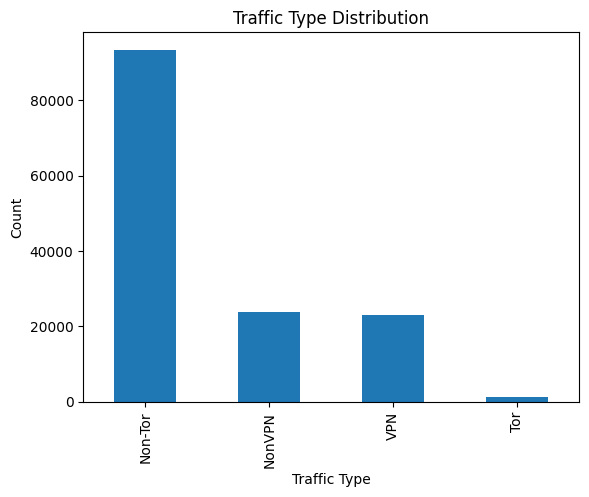

In [ ]:
import matplotlib.pyplot as plt

df['Label'].value_counts().plot(kind='bar')

plt.title('Traffic Type Distribution')
plt.xlabel('Traffic Type')
plt.ylabel('Count')

plt.show()